# Bước 6: Regression Analysis
## UK Weather & Health: Weekly Deaths and Temperature (2016–2024)

**Mục tiêu**: Dự báo `deaths_total` dựa trên các biến nhiệt độ & lag. Kiểm định ý nghĩa thống kê, đánh giá mô hình, phân tích residual.

---

## 6.1 Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

# Load dataset
df = pd.read_csv('uk_weather_health_weekly_CLEANED.csv',
                  parse_dates=['week_start_sat', 'week_start_mon', 'week_end'])
df = df.sort_values('week_start_mon').reset_index(drop=True)

print(f'Dataset: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(3)

Dataset: 469 rows × 13 columns


,week_start_sat,week_start_mon,week_end,deaths_total,tasmax_mean_weekly_degC,tasmax_max_weekly_degC,year,month,week_of_year,quarter,season,temp_range_weekly,IsSurge
0,2016-01-02,2016-01-04,2016-01-08,13045.0,7.363329,8.839454,2016,1,1,1,Winter,1.476125,1
1,2016-01-09,2016-01-11,2016-01-15,11501.0,5.132909,7.135659,2016,1,2,1,Winter,2.002750,1
2,2016-01-16,2016-01-18,2016-01-22,11473.0,5.359014,10.233992,2016,1,3,1,Winter,4.874978,0


## 6.2 Feature Engineering — Tạo biến đầu vào cho mô hình

In [2]:
# Tạo lag_1_deaths: tử vong tuần trước
df['lag_1_deaths'] = df['deaths_total'].shift(1)

# Tạo month_index (= month) — đã có sẵn trong dataset
# Tạo biến month dummy (One-Hot Encoding)
df = pd.get_dummies(df, columns=['month'], drop_first=True, dtype=int)

# Tạo biến mùa hè
df['is_summer'] = (df['season'] == 'Summer').astype(int)

# Tạo biến tương tác: nhiệt độ × mùa hè (để đo hiệu ứng nhiệt mùa hè)
df['temp_x_summer'] = df['tasmax_mean_weekly_degC'] * df['is_summer']

# Drop hàng đầu tiên (NaN do lag)
df_model = df.dropna(subset=['lag_1_deaths']).copy()

print(f'Dataset sau feature engineering: {df_model.shape[0]} rows')
print(f'\nCác biến mới:')
print(f'  lag_1_deaths: tử vong tuần trước (t-1)')
print(f'  is_summer:    1 nếu mùa hè, 0 nếu không')
print(f'  temp_x_summer: tasmax_mean × is_summer (interaction term)')
print(f'\nThống kê biến mới:')
df_model[['lag_1_deaths', 'is_summer', 'temp_x_summer']].describe().round(2)

Dataset sau feature engineering: 468 rows

Các biến mới:
  lag_1_deaths: tử vong tuần trước (t-1)
  is_summer:    1 nếu mùa hè, 0 nếu không
  temp_x_summer: tasmax_mean × is_summer (interaction term)

Thống kê biến mới:


,lag_1_deaths,is_summer,temp_x_summer
count,468.00,468.00,468.00
mean,10748.38,0.25,4.92
std,1851.99,0.43,8.55
min,6825.00,0.00,0.00
25%,9635.75,0.00,0.00
50%,10471.00,0.00,0.00
75%,11484.50,1.00,14.37
max,22351.00,1.00,25.45


## 6.3 Kiểm tra Đa cộng tuyến (VIF) giữa `tasmax_mean` và `tasmax_max`

In [3]:
# Kiểm tra VIF cho các biến nhiệt độ
month_cols = [c for c in df_model.columns if c.startswith('month_')]
vif_cols = ['tasmax_mean_weekly_degC', 'tasmax_max_weekly_degC', 'lag_1_deaths'] + month_cols
X_vif = df_model[vif_cols].copy()
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame({
    'Biến': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).round(2)

print('KIỂM TRA ĐA CỘNG TUYẾN (VIF):')
print('=' * 50)
print(vif_data.to_string(index=False))
print()

# Tương quan giữa 2 biến nhiệt độ
r_temp, p_temp = stats.pearsonr(df_model['tasmax_mean_weekly_degC'], df_model['tasmax_max_weekly_degC'])
print(f'Pearson r (tasmax_mean vs tasmax_max) = {r_temp:.4f}, p = {p_temp:.2e}')

if vif_data[vif_data['Biến'] == 'tasmax_max_weekly_degC']['VIF'].values[0] > 10:
    print('\n  VIF > 10 → Đa cộng tuyến CAO giữa tasmax_mean & tasmax_max')
    print('→ Quyết định: LOẠI BỎ tasmax_max, chỉ giữ tasmax_mean để tránh multicollinearity')
    drop_tasmax_max = True
else:
    print('\n VIF < 10 → Có thể giữ cả hai biến nhiệt độ')
    drop_tasmax_max = False

KIỂM TRA ĐA CỘNG TUYẾN (VIF):
                   Biến   VIF
                  const 92.51
tasmax_mean_weekly_degC 28.73
 tasmax_max_weekly_degC 20.99
           lag_1_deaths  1.51
                month_2  1.79
                month_3  2.00
                month_4  2.35
                month_5  3.47
                month_6  4.38
                month_7  5.32
                month_8  5.00
                month_9  3.96
               month_10  2.86
               month_11  1.99
               month_12  1.87

Pearson r (tasmax_mean vs tasmax_max) = 0.9743, p = 1.17e-303

  VIF > 10 → Đa cộng tuyến CAO giữa tasmax_mean & tasmax_max
→ Quyết định: LOẠI BỎ tasmax_max, chỉ giữ tasmax_mean để tránh multicollinearity


## 6.4 Mô hình 1: OLS Linear Regression (Baseline)

**Biến đầu vào**: `tasmax_mean`, `month`, `lag_1_deaths`  
**Biến mục tiêu**: `deaths_total`

In [4]:
# Chọn features sau khi loại bỏ đa cộng tuyến
month_cols = [c for c in df_model.columns if c.startswith('month_')]
feature_cols = ['tasmax_mean_weekly_degC', 'lag_1_deaths'] + month_cols
target = 'deaths_total'

X = df_model[feature_cols]
y = df_model[target]

# Train/Test split: 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# OLS với statsmodels (để có p-value, CI, F-test)
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:           deaths_total   R-squared:                       0.679
Model:                            OLS   Adj. R-squared:                  0.667
Method:                 Least Squares   F-statistic:                     58.57
Date:                Sun, 08 Mar 2026   Prob (F-statistic):           1.75e-80
Time:                        20:27:20   Log-Likelihood:                -3159.5
No. Observations:                 374   AIC:                             6347.
Df Residuals:                     360   BIC:                             6402.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    5

## 6.5 Kiểm định ý nghĩa thống kê — Nhiệt độ có ảnh hưởng đến tử vong?

In [5]:
print('KIỂM ĐỊNH Ý NGHĨA THỐNG KÊ CỦA CÁC BIẾN:')
print('=' * 65)

results_df = pd.DataFrame({
    'Biến': ols_model.params.index,
    'Hệ số (β)': ols_model.params.values,
    'Std Error': ols_model.bse.values,
    't-value': ols_model.tvalues.values,
    'p-value': ols_model.pvalues.values,
    'Significant?': [' Yes' if p < 0.05 else ' No' for p in ols_model.pvalues.values]
}).round(4)

print(results_df.to_string(index=False))

print(f'\n--- Kiểm định tổng thể ---')
print(f'F-statistic = {ols_model.fvalue:.2f}, p(F) = {ols_model.f_pvalue:.2e}')
print(f'R² (train) = {ols_model.rsquared:.4f}')
print(f'Adj R² (train) = {ols_model.rsquared_adj:.4f}')

# Giải thích hệ số nhiệt độ
coef_temp = ols_model.params['tasmax_mean_weekly_degC']
p_temp = ols_model.pvalues['tasmax_mean_weekly_degC']
print(f'\n--- Giải thích hệ số nhiệt độ ---')
print(f'β(tasmax_mean) = {coef_temp:.2f}')
print(f'p-value = {p_temp:.4f}')
if p_temp < 0.05:
    print(f'→ Nhiệt độ CÓ ý nghĩa thống kê (p < 0.05)')
    print(f'→ Khi nhiệt độ tăng 1°C (giữ các biến khác không đổi), tử vong thay đổi {coef_temp:.1f} ca/tuần')
else:
    print(f'→ Nhiệt độ KHÔNG có ý nghĩa thống kê trong mô hình này (p ≥ 0.05)')

KIỂM ĐỊNH Ý NGHĨA THỐNG KÊ CỦA CÁC BIẾN:
                   Biến  Hệ số (β)  Std Error  t-value  p-value Significant?
                  const  5019.7429   541.9592   9.2622   0.0000          Yes
tasmax_mean_weekly_degC    12.2088    28.5123   0.4282   0.6688           No
           lag_1_deaths     0.6552     0.0364  17.9754   0.0000          Yes
                month_2 -1265.9747   280.9054  -4.5068   0.0000          Yes
                month_3 -1477.7667   301.2518  -4.9054   0.0000          Yes
                month_4  -961.6983   327.4267  -2.9371   0.0035          Yes
                month_5 -2292.7501   386.8540  -5.9267   0.0000          Yes
                month_6 -1750.7647   457.7805  -3.8245   0.0002          Yes
                month_7 -2004.2888   496.6899  -4.0353   0.0001          Yes
                month_8 -2264.8378   475.6116  -4.7619   0.0000          Yes
                month_9 -1605.9328   432.1580  -3.7161   0.0002          Yes
               month_10 -1528.1810 

## 6.6 Hiệu ứng nhiệt độ mùa hè — Khi tăng 1°C vào mùa hè, tử vong tăng bao nhiêu?

In [6]:
# Mô hình OLS với interaction term (temp × summer)
month_cols = [c for c in df_model.columns if c.startswith('month_')]
feature_summer = ['tasmax_mean_weekly_degC', 'lag_1_deaths', 'is_summer', 'temp_x_summer'] + month_cols

X_summer = df_model[feature_summer]
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_summer, y, test_size=0.2, shuffle=False)

X_train_s_sm = sm.add_constant(X_train_s)
ols_summer = sm.OLS(y_train_s, X_train_s_sm).fit()

print('MÔ HÌNH VỚI INTERACTION TERM (Nhiệt độ × Mùa hè):')
print('=' * 65)
print(ols_summer.summary2().tables[1].to_string())

coef_temp_base = ols_summer.params['tasmax_mean_weekly_degC']
coef_interaction = ols_summer.params['temp_x_summer']
p_interaction = ols_summer.pvalues['temp_x_summer']

summer_effect = coef_temp_base + coef_interaction

print(f'\n--- Hiệu ứng nhiệt độ theo mùa ---')
print(f'Hiệu ứng nhiệt độ NGOÀI mùa hè: {coef_temp_base:.2f} ca/°C')
print(f'Hiệu ứng thêm trong MÙA HÈ:     {coef_interaction:.2f} ca/°C')
print(f'Tổng hiệu ứng MÙA HÈ:            {summer_effect:.2f} ca/°C')
print(f'p-value (interaction):             {p_interaction:.4f}')
print(f'\n→ Khi nhiệt độ tăng 1°C vào mùa hè, tử vong thay đổi khoảng {summer_effect:.0f} ca/tuần')
if p_interaction < 0.05:
    print('→ Hiệu ứng interaction CÓ ý nghĩa thống kê')
else:
    print('→ Hiệu ứng interaction KHÔNG có ý nghĩa thống kê — hiệu ứng mùa hè tương tự các mùa khác')

MÔ HÌNH VỚI INTERACTION TERM (Nhiệt độ × Mùa hè):
                               Coef.    Std.Err.          t         P>|t|       [0.025       0.975]
const                    5153.939347  555.685813   9.274916  1.700996e-18  4061.130996  6246.747699
tasmax_mean_weekly_degC    -5.905499   33.011994  -0.178890  8.581254e-01   -70.826687    59.015689
lag_1_deaths                0.654607    0.036443  17.962525  6.310832e-52     0.582938     0.726275
is_summer               -2378.237538  869.348277  -2.735656  6.534787e-03 -4087.892590  -668.582486
temp_x_summer              71.145569   65.398204   1.087883  2.773767e-01   -57.466142   199.757280
month_2                 -1253.891117  281.053367  -4.461399  1.091018e-05 -1806.608965  -701.173270
month_3                 -1431.320049  304.186168  -4.705408  3.621941e-06 -2029.530724  -833.109375
month_4                  -867.766106  338.539372  -2.563265  1.077606e-02 -1533.535583  -201.996628
month_5                 -2136.290102  412.630753  

## 6.7 Đánh giá mô hình OLS — $R^2$ và RMSE

ĐÁNH GIÁ MÔ HÌNH OLS LINEAR REGRESSION:
  Metric     Train      Test
      R²    0.6790    0.1695
  Adj R²    0.6674       NaN
    RMSE 1128.9041 1049.0247
     MAE  706.9558  668.4018
MAPE (%)    6.4766    6.6568


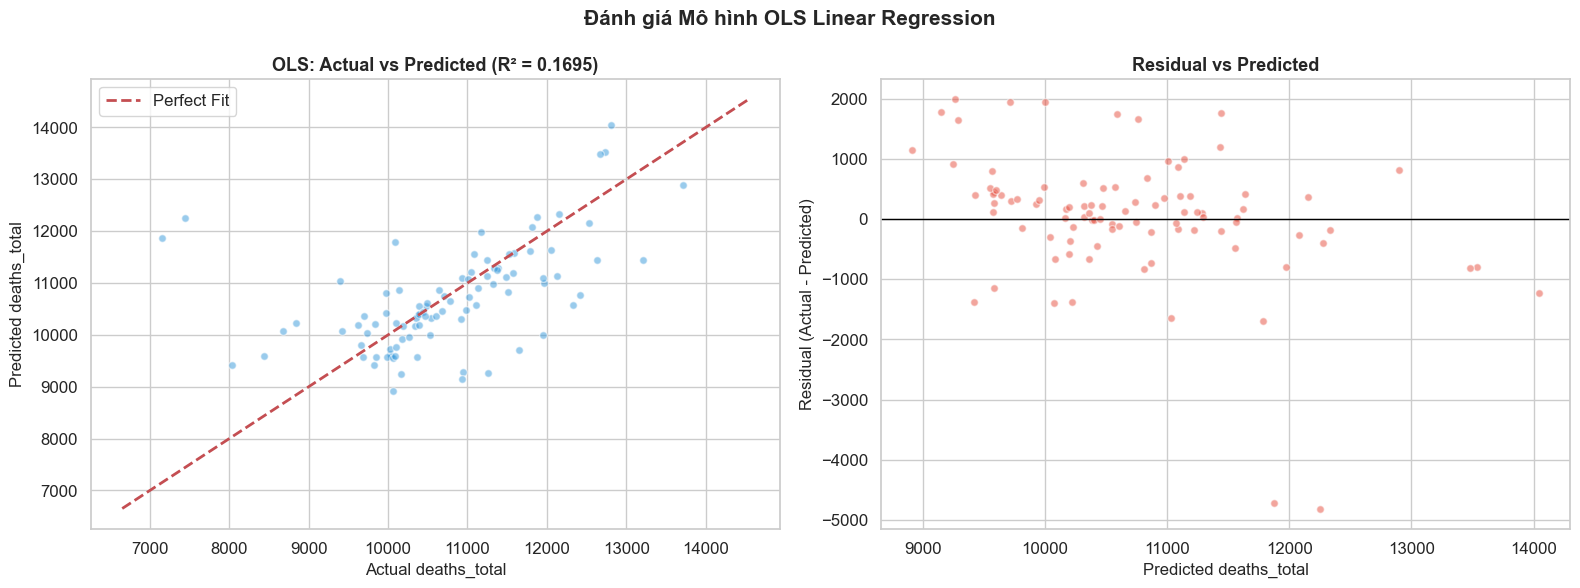

In [7]:
# Dự báo trên test set
y_pred_train = ols_model.predict(X_train_sm)
y_pred_test = ols_model.predict(X_test_sm)

# Metrics
metrics = {
    'Metric': ['R²', 'Adj R²', 'RMSE', 'MAE', 'MAPE (%)'],
    'Train': [
        r2_score(y_train, y_pred_train),
        ols_model.rsquared_adj,
        np.sqrt(mean_squared_error(y_train, y_pred_train)),
        mean_absolute_error(y_train, y_pred_train),
        np.mean(np.abs((y_train - y_pred_train) / y_train)) * 100
    ],
    'Test': [
        r2_score(y_test, y_pred_test),
        np.nan,  # Adj R² chỉ có cho train
        np.sqrt(mean_squared_error(y_test, y_pred_test)),
        mean_absolute_error(y_test, y_pred_test),
        np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100
    ]
}
metrics_df = pd.DataFrame(metrics).round(4)

print('ĐÁNH GIÁ MÔ HÌNH OLS LINEAR REGRESSION:')
print('=' * 50)
print(metrics_df.to_string(index=False))

# Visualize Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter actual vs predicted
axes[0].scatter(y_test, y_pred_test, alpha=0.5, s=30, color='#3498db', edgecolor='white')
min_val = min(y_test.min(), y_pred_test.min()) - 500
max_val = max(y_test.max(), y_pred_test.max()) + 500
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')
axes[0].set_xlabel('Actual deaths_total', fontsize=12)
axes[0].set_ylabel('Predicted deaths_total', fontsize=12)
axes[0].set_title(f'OLS: Actual vs Predicted (R² = {r2_score(y_test, y_pred_test):.4f})',
                   fontweight='bold', fontsize=13)
axes[0].legend()

# Prediction error plot
errors = y_test.values - y_pred_test
axes[1].scatter(y_pred_test, errors, alpha=0.5, s=30, color='#e74c3c', edgecolor='white')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Predicted deaths_total', fontsize=12)
axes[1].set_ylabel('Residual (Actual - Predicted)', fontsize=12)
axes[1].set_title('Residual vs Predicted', fontweight='bold', fontsize=13)

plt.suptitle('Đánh giá Mô hình OLS Linear Regression', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 6.8 Polynomial Regression — Khớp hình chữ U

SO SÁNH LINEAR vs POLYNOMIAL REGRESSION:
 Degree  R² (test)  RMSE (test)  MAE (test)  Num Features
      1     0.1695    1049.0247    668.4018            13
      2     0.3243     946.2378    650.0166           104
      3     0.0920    1096.8983    710.4349           559


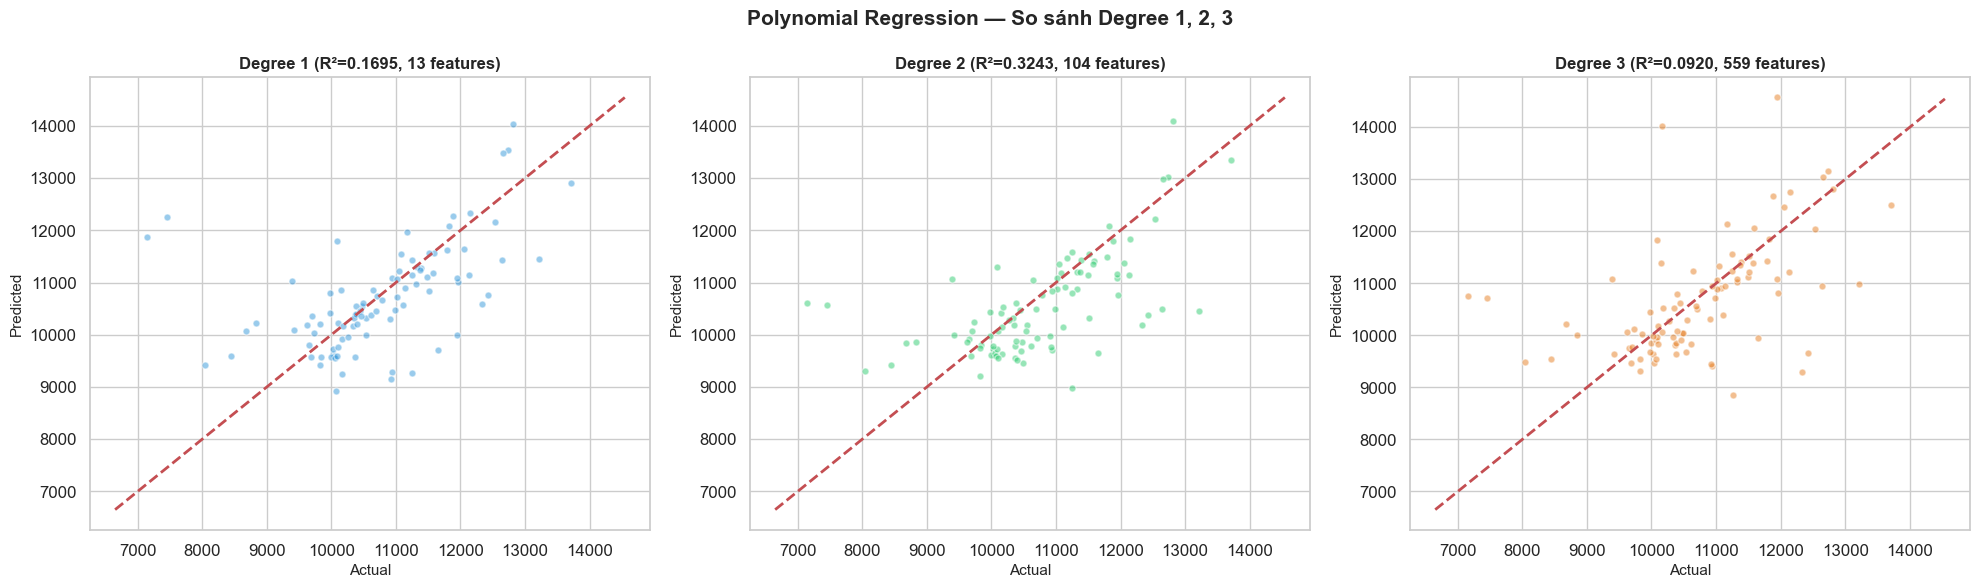


→ Degree 2 cho R² cao nhất = 0.3243
→ CÓ cần Polynomial: hình chữ U được khớp tốt hơn với bậc > 1


In [8]:
# So sánh Linear vs Polynomial (degree 2, 3)
results_poly = []

for degree in [1, 2, 3]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('reg', LinearRegression())
    ])
    pipe.fit(X_train, y_train)
    y_pred_p = pipe.predict(X_test)

    results_poly.append({
        'Degree': degree,
        'R² (test)': r2_score(y_test, y_pred_p),
        'RMSE (test)': np.sqrt(mean_squared_error(y_test, y_pred_p)),
        'MAE (test)': mean_absolute_error(y_test, y_pred_p),
        'Num Features': pipe.named_steps['poly'].n_output_features_
    })

poly_df = pd.DataFrame(results_poly).round(4)
print('SO SÁNH LINEAR vs POLYNOMIAL REGRESSION:')
print('=' * 65)
print(poly_df.to_string(index=False))

# Biểu đồ so sánh
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors_deg = ['#3498db', '#2ecc71', '#e67e22']

for idx, degree in enumerate([1, 2, 3]):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('reg', LinearRegression())
    ])
    pipe.fit(X_train, y_train)
    y_pred_p = pipe.predict(X_test)
    r2 = r2_score(y_test, y_pred_p)

    axes[idx].scatter(y_test, y_pred_p, alpha=0.5, s=25, color=colors_deg[idx], edgecolor='white')
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    axes[idx].set_xlabel('Actual', fontsize=11)
    axes[idx].set_ylabel('Predicted', fontsize=11)
    axes[idx].set_title(f'Degree {degree} (R²={r2:.4f}, {results_poly[idx]["Num Features"]} features)',
                         fontweight='bold', fontsize=12)

plt.suptitle('Polynomial Regression — So sánh Degree 1, 2, 3', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

best = poly_df.loc[poly_df['R² (test)'].idxmax()]
print(f'\n→ Degree {int(best["Degree"])} cho R² cao nhất = {best["R² (test)"]:.4f}')
if best['Degree'] > 1:
    print('→ CÓ cần Polynomial: hình chữ U được khớp tốt hơn với bậc > 1')
else:
    print('→ KHÔNG cần Polynomial: Linear đã đủ tốt')

## 6.9 Residual Analysis — Sai số phân bố ngẫu nhiên?

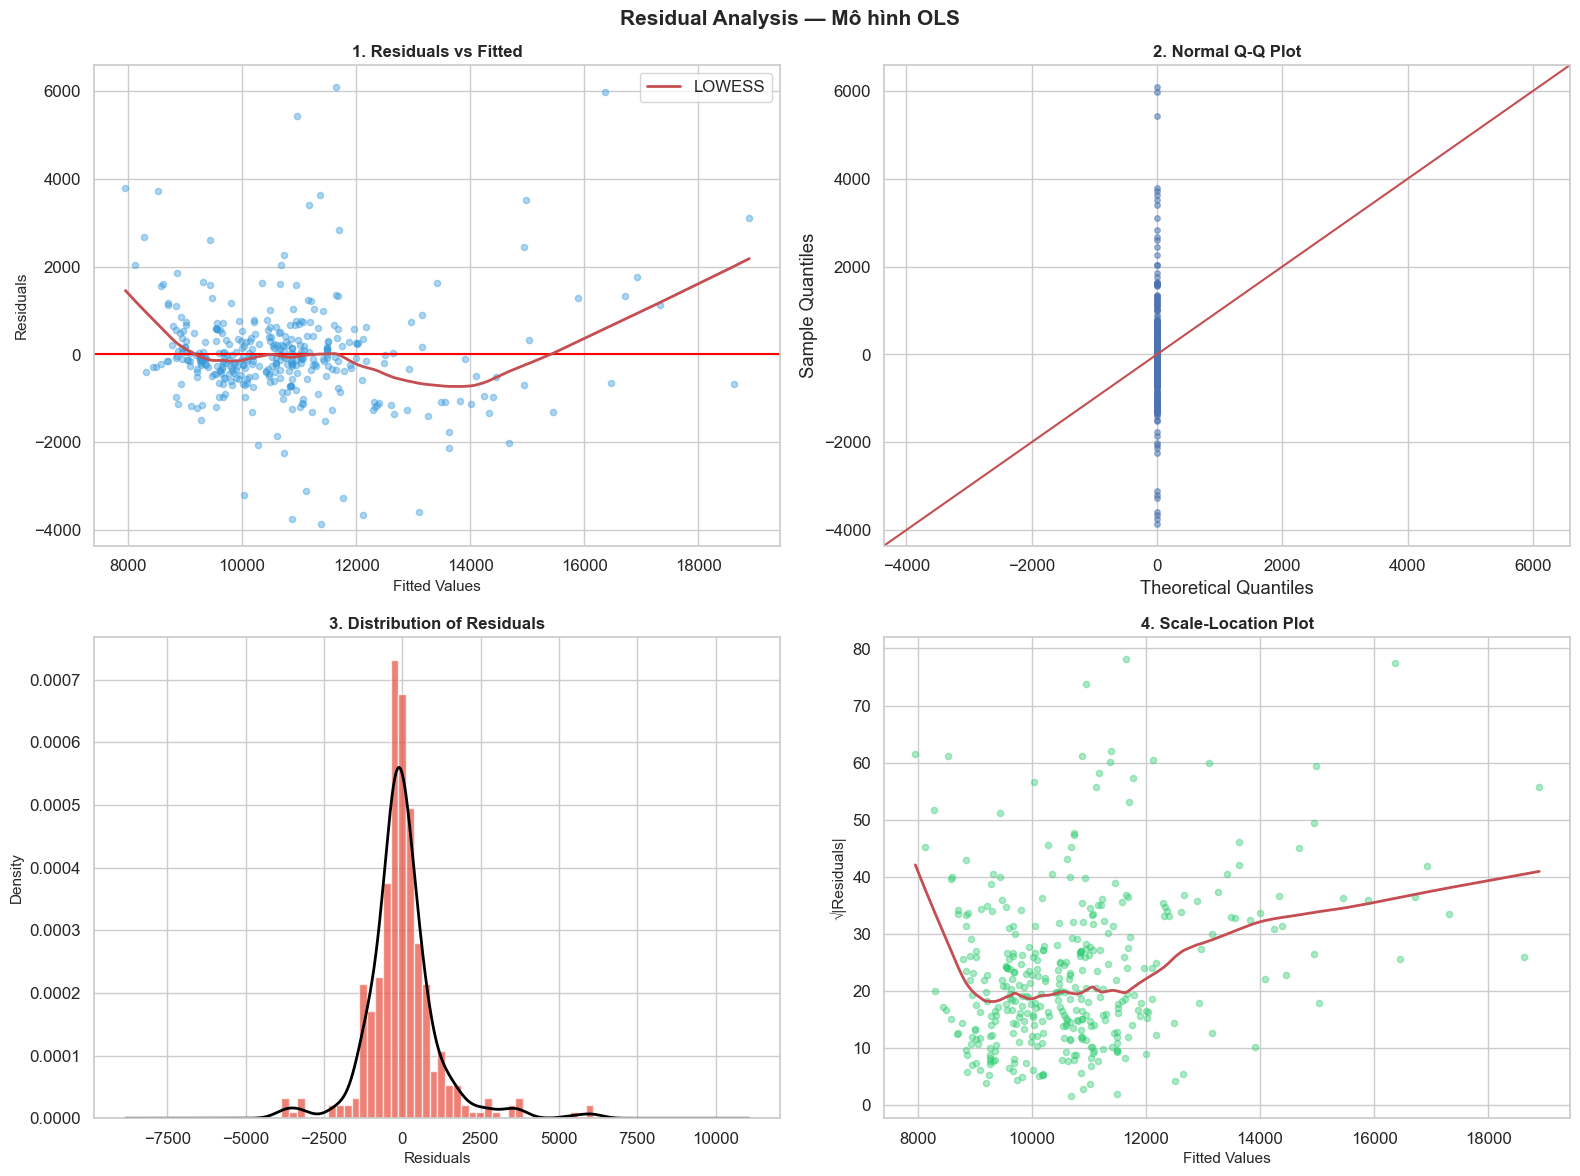

KIỂM ĐỊNH RESIDUALS:
Shapiro-Wilk (normality): W=0.8595, p=0.0000 → Residuals NOT normal
Durbin-Watson (autocorr): DW=2.0153 → No significant autocorrelation 
Breusch-Pagan (heterosc): χ²=46.8979, p=0.0000 → Heteroscedasticity 


In [9]:
# Residuals từ mô hình OLS
residuals_train = ols_model.resid
fitted_train = ols_model.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Residuals vs Fitted
axes[0, 0].scatter(fitted_train, residuals_train, alpha=0.4, s=20, color='#3498db')
axes[0, 0].axhline(0, color='red', linewidth=1.5)
axes[0, 0].set_xlabel('Fitted Values', fontsize=11)
axes[0, 0].set_ylabel('Residuals', fontsize=11)
axes[0, 0].set_title('1. Residuals vs Fitted', fontweight='bold', fontsize=12)

# Thêm lowess smoothing
lowess = sm.nonparametric.lowess(residuals_train, fitted_train, frac=0.3)
axes[0, 0].plot(lowess[:, 0], lowess[:, 1], 'r-', linewidth=2, label='LOWESS')
axes[0, 0].legend()

# 2. QQ-Plot
sm.qqplot(residuals_train, line='45', ax=axes[0, 1], markersize=4, alpha=0.5)
axes[0, 1].set_title('2. Normal Q-Q Plot', fontweight='bold', fontsize=12)

# 3. Histogram of Residuals
axes[1, 0].hist(residuals_train, bins=40, color='#e74c3c', edgecolor='white', alpha=0.7, density=True)
residuals_train.plot.kde(ax=axes[1, 0], color='black', linewidth=2)
axes[1, 0].set_xlabel('Residuals', fontsize=11)
axes[1, 0].set_ylabel('Density', fontsize=11)
axes[1, 0].set_title('3. Distribution of Residuals', fontweight='bold', fontsize=12)

# 4. Scale-Location (sqrt(|residuals|) vs fitted)
sqrt_resid = np.sqrt(np.abs(residuals_train))
axes[1, 1].scatter(fitted_train, sqrt_resid, alpha=0.4, s=20, color='#2ecc71')
lowess2 = sm.nonparametric.lowess(sqrt_resid, fitted_train, frac=0.3)
axes[1, 1].plot(lowess2[:, 0], lowess2[:, 1], 'r-', linewidth=2)
axes[1, 1].set_xlabel('Fitted Values', fontsize=11)
axes[1, 1].set_ylabel('√|Residuals|', fontsize=11)
axes[1, 1].set_title('4. Scale-Location Plot', fontweight='bold', fontsize=12)

plt.suptitle('Residual Analysis — Mô hình OLS', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Kiểm định thống kê
print('KIỂM ĐỊNH RESIDUALS:')
print('=' * 55)

# Shapiro-Wilk test (normality)
stat_sw, p_sw = stats.shapiro(residuals_train[:500])  # max 5000 samples
print(f'Shapiro-Wilk (normality): W={stat_sw:.4f}, p={p_sw:.4f}', end='')
print(' → Residuals NOT normal' if p_sw < 0.05 else ' → Residuals ~normal')

# Durbin-Watson (autocorrelation)
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals_train)
print(f'Durbin-Watson (autocorr): DW={dw:.4f}', end='')
if dw < 1.5:
    print(' → Positive autocorrelation ')
elif dw > 2.5:
    print(' → Negative autocorrelation ')
else:
    print(' → No significant autocorrelation ')

# Breusch-Pagan test (heteroscedasticity)
bp_stat, bp_p, _, _ = het_breuschpagan(residuals_train, X_train_sm)
print(f'Breusch-Pagan (heterosc): χ²={bp_stat:.4f}, p={bp_p:.4f}', end='')
print(' → Heteroscedasticity ' if bp_p < 0.05 else ' → Homoscedasticity ')

## 6.10 Regularization — Ridge & Lasso để tránh Overfitting

SO SÁNH OLS vs RIDGE vs LASSO:
         Model Alpha  R² Train  R² Test  RMSE Test
OLS (baseline)     -    0.6790   0.1695  1049.0247
         Ridge  0.01    0.6790   0.1695  1049.0348
         Lasso  0.01    0.6790   0.1695  1049.0395
         Ridge   0.1    0.6790   0.1694  1049.1259
         Lasso   0.1    0.6790   0.1693  1049.1744
         Ridge     1    0.6789   0.1679  1050.0397
         Lasso     1    0.6789   0.1670  1050.6279
         Ridge    10    0.6757   0.1577  1056.4624
         Lasso    10    0.6746   0.1411  1066.8016
         Ridge   100    0.6384   0.1910  1035.3663
         Lasso   100    0.6368   0.0554  1118.8118
         Ridge  1000    0.3736   0.2512   996.1167
         Lasso  1000    0.3607   0.1049  1089.0832


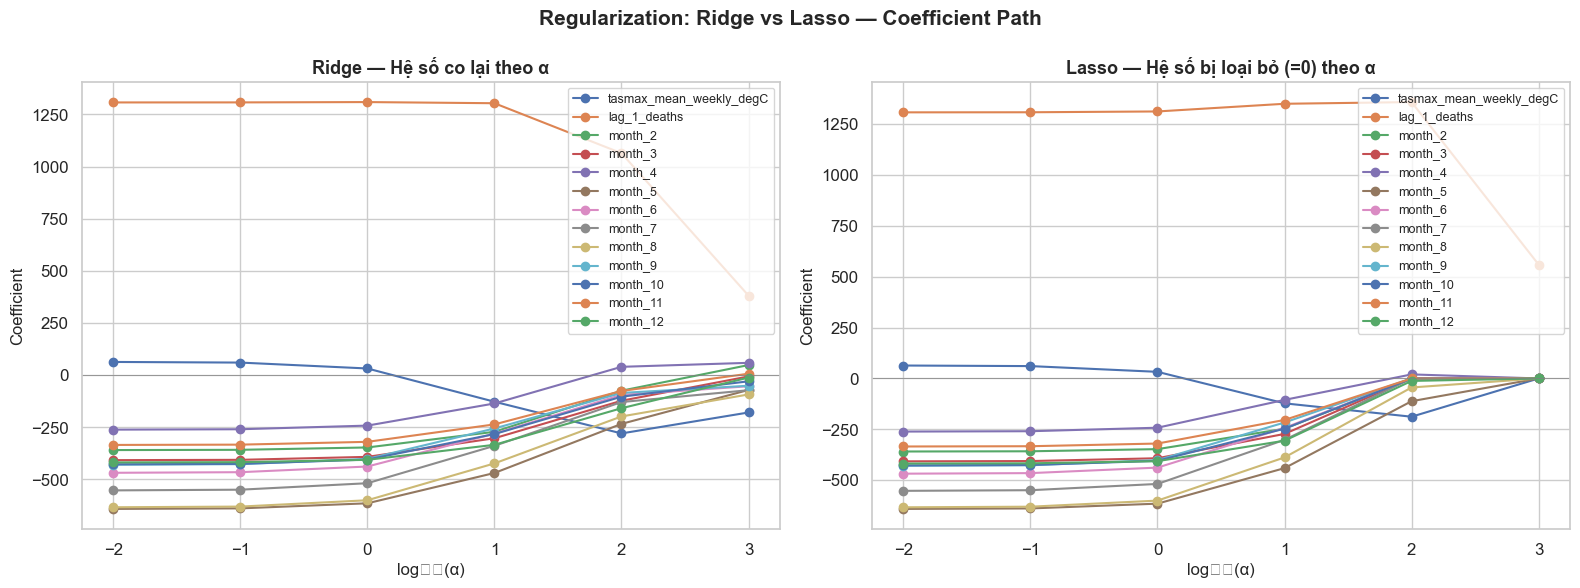


→ Best: Ridge (α=1000), R²=0.2512, RMSE=996.1


In [10]:
# Chuẩn hóa features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# So sánh Ridge & Lasso với nhiều alpha
alphas = [0.01, 0.1, 1, 10, 100, 1000]
reg_results = []

# OLS baseline
lr = LinearRegression().fit(X_train_scaled, y_train)
reg_results.append({
    'Model': 'OLS (baseline)', 'Alpha': '-',
    'R² Train': r2_score(y_train, lr.predict(X_train_scaled)),
    'R² Test': r2_score(y_test, lr.predict(X_test_scaled)),
    'RMSE Test': np.sqrt(mean_squared_error(y_test, lr.predict(X_test_scaled)))
})

for alpha in alphas:
    # Ridge
    ridge = Ridge(alpha=alpha).fit(X_train_scaled, y_train)
    reg_results.append({
        'Model': 'Ridge', 'Alpha': alpha,
        'R² Train': r2_score(y_train, ridge.predict(X_train_scaled)),
        'R² Test': r2_score(y_test, ridge.predict(X_test_scaled)),
        'RMSE Test': np.sqrt(mean_squared_error(y_test, ridge.predict(X_test_scaled)))
    })
    # Lasso
    lasso = Lasso(alpha=alpha, max_iter=10000).fit(X_train_scaled, y_train)
    reg_results.append({
        'Model': 'Lasso', 'Alpha': alpha,
        'R² Train': r2_score(y_train, lasso.predict(X_train_scaled)),
        'R² Test': r2_score(y_test, lasso.predict(X_test_scaled)),
        'RMSE Test': np.sqrt(mean_squared_error(y_test, lasso.predict(X_test_scaled)))
    })

reg_df = pd.DataFrame(reg_results).round(4)
print('SO SÁNH OLS vs RIDGE vs LASSO:')
print('=' * 70)
print(reg_df.to_string(index=False))

# Biểu đồ hệ số theo alpha
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ridge_coefs = []
lasso_coefs = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha).fit(X_train_scaled, y_train)
    lasso = Lasso(alpha=alpha, max_iter=10000).fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge.coef_)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

for i, col in enumerate(feature_cols):
    axes[0].plot(np.log10(alphas), ridge_coefs[:, i], marker='o', label=col)
    axes[1].plot(np.log10(alphas), lasso_coefs[:, i], marker='o', label=col)

axes[0].set_xlabel('log₁₀(α)', fontsize=12)
axes[0].set_ylabel('Coefficient', fontsize=12)
axes[0].set_title('Ridge — Hệ số co lại theo α', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=9)
axes[0].axhline(0, color='gray', linewidth=0.5)

axes[1].set_xlabel('log₁₀(α)', fontsize=12)
axes[1].set_ylabel('Coefficient', fontsize=12)
axes[1].set_title('Lasso — Hệ số bị loại bỏ (=0) theo α', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=9)
axes[1].axhline(0, color='gray', linewidth=0.5)

plt.suptitle('Regularization: Ridge vs Lasso — Coefficient Path', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Best model
best_reg = reg_df.loc[reg_df['R² Test'].idxmax()]
print(f'\n→ Best: {best_reg["Model"]} (α={best_reg["Alpha"]}), R²={best_reg["R² Test"]:.4f}, RMSE={best_reg["RMSE Test"]:.1f}')

## 6.11 Mô hình tổng hợp cuối cùng — So sánh tất cả

BẢNG TỔNG HỢP — SO SÁNH TẤT CẢ MÔ HÌNH:
                Mô hình  R² Test  RMSE Test  MAE Test
          1. OLS Linear   0.1695  1049.0247  668.4018
  2. Polynomial (deg=2)   0.3243   946.2378  650.0166
3. Ridge Poly2 (α=1000)   0.2999   963.1466  684.9659
4. Lasso Poly2 (α=0.01)   0.3244   946.1673  649.9041


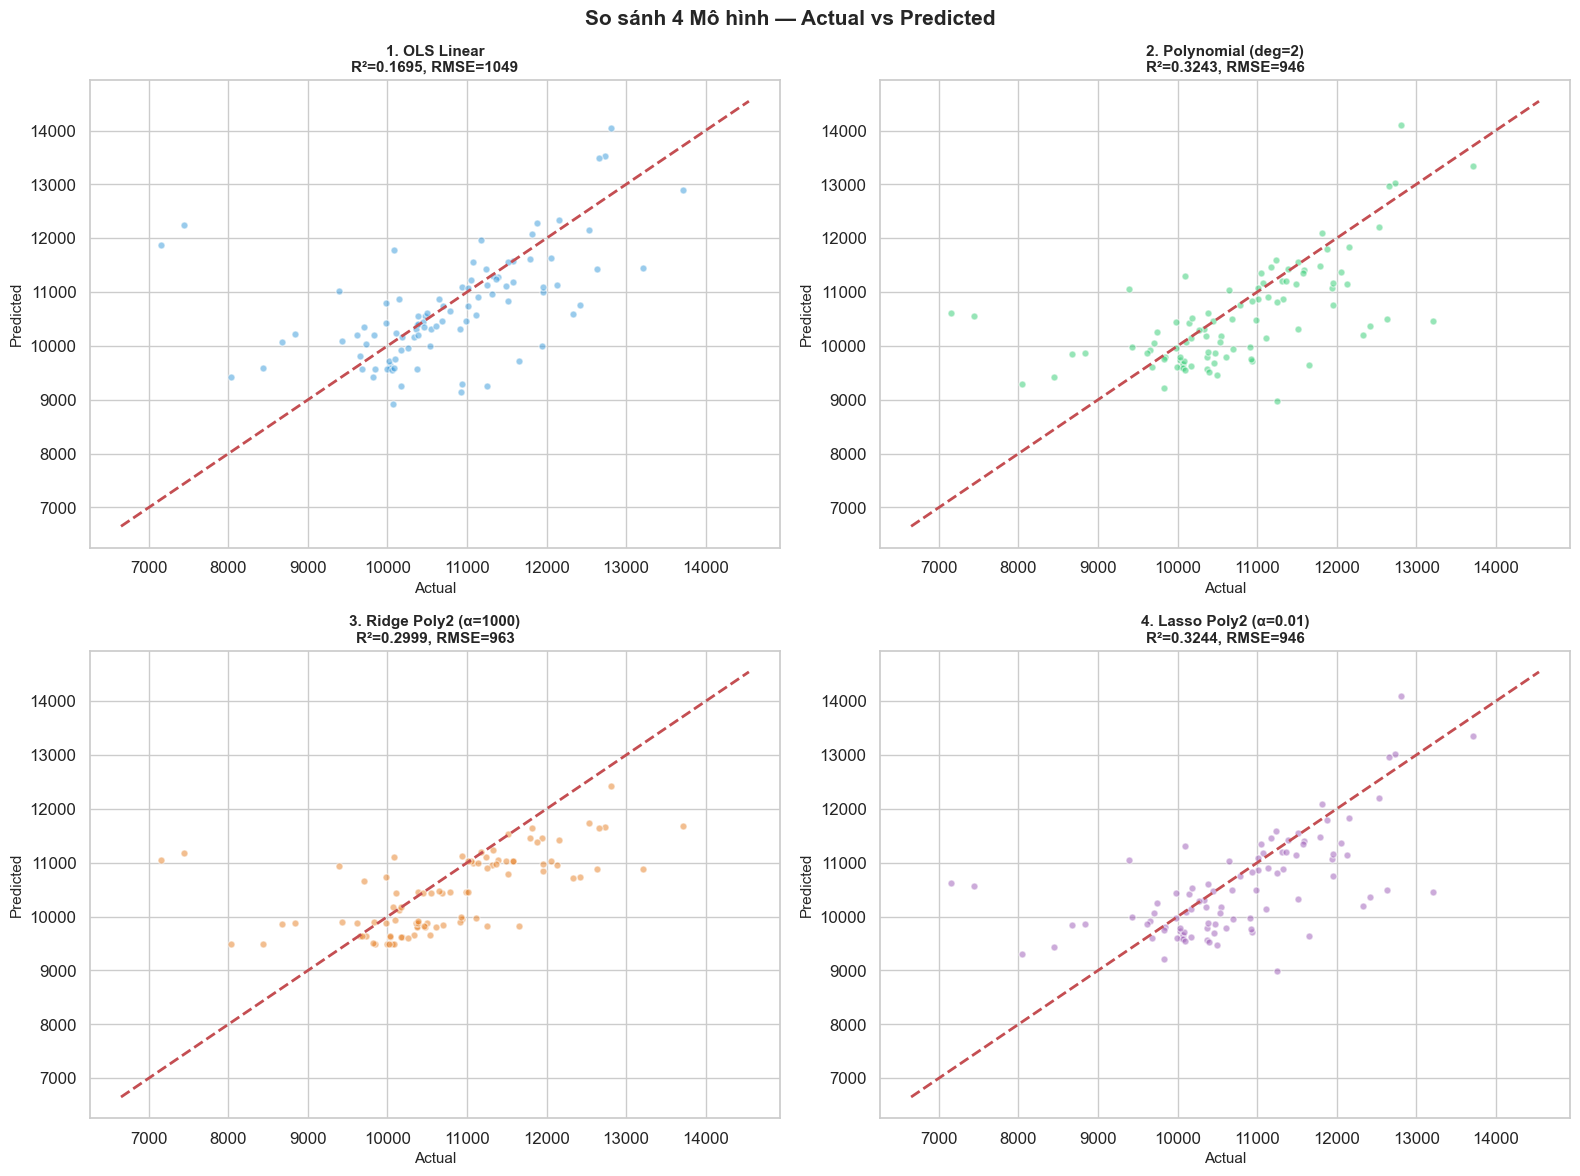


 MÔ HÌNH TỐT NHẤT: 4. Lasso Poly2 (α=0.01)
   R² = 0.3244, RMSE = 946.2, MAE = 649.9


In [11]:
# Tổng hợp tất cả mô hình
final_models = []

# 1. OLS
lr_final = LinearRegression().fit(X_train, y_train)
y_pred_ols = lr_final.predict(X_test)
final_models.append({
    'Mô hình': '1. OLS Linear',
    'R² Test': r2_score(y_test, y_pred_ols),
    'RMSE Test': np.sqrt(mean_squared_error(y_test, y_pred_ols)),
    'MAE Test': mean_absolute_error(y_test, y_pred_ols)
})

# 2. Polynomial degree 2
pipe2 = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('reg', LinearRegression())
])
pipe2.fit(X_train, y_train)
y_pred_poly2 = pipe2.predict(X_test)
final_models.append({
    'Mô hình': '2. Polynomial (deg=2)',
    'R² Test': r2_score(y_test, y_pred_poly2),
    'RMSE Test': np.sqrt(mean_squared_error(y_test, y_pred_poly2)),
    'MAE Test': mean_absolute_error(y_test, y_pred_poly2)
})

# 3. Ridge (best alpha)
best_alpha_ridge = reg_df[reg_df['Model'] == 'Ridge'].sort_values('R² Test', ascending=False).iloc[0]['Alpha']
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('reg', Ridge(alpha=float(best_alpha_ridge)))
])
pipe_ridge.fit(X_train, y_train)
y_pred_ridge = pipe_ridge.predict(X_test)
final_models.append({
    'Mô hình': f'3. Ridge Poly2 (α={best_alpha_ridge})',
    'R² Test': r2_score(y_test, y_pred_ridge),
    'RMSE Test': np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
    'MAE Test': mean_absolute_error(y_test, y_pred_ridge)
})

# 4. Lasso (best alpha)
best_alpha_lasso = reg_df[reg_df['Model'] == 'Lasso'].sort_values('R² Test', ascending=False).iloc[0]['Alpha']
pipe_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('reg', Lasso(alpha=float(best_alpha_lasso), max_iter=10000))
])
pipe_lasso.fit(X_train, y_train)
y_pred_lasso = pipe_lasso.predict(X_test)
final_models.append({
    'Mô hình': f'4. Lasso Poly2 (α={best_alpha_lasso})',
    'R² Test': r2_score(y_test, y_pred_lasso),
    'RMSE Test': np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
    'MAE Test': mean_absolute_error(y_test, y_pred_lasso)
})

final_df = pd.DataFrame(final_models).round(4)
print('BẢNG TỔNG HỢP — SO SÁNH TẤT CẢ MÔ HÌNH:')
print('=' * 65)
print(final_df.to_string(index=False))

# Biểu đồ so sánh
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
model_names = final_df['Mô hình'].tolist()
predictions = [y_pred_ols, y_pred_poly2, y_pred_ridge, y_pred_lasso]
colors_m = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

for idx, (ax, name, pred, color) in enumerate(zip(axes.flat, model_names, predictions, colors_m)):
    ax.scatter(y_test, pred, alpha=0.5, s=25, color=color, edgecolor='white')
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    ax.set_xlabel('Actual', fontsize=11)
    ax.set_ylabel('Predicted', fontsize=11)
    ax.set_title(f'{name}\nR²={r2:.4f}, RMSE={rmse:.0f}', fontweight='bold', fontsize=11)

plt.suptitle('So sánh 4 Mô hình — Actual vs Predicted', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

winner = final_df.loc[final_df['R² Test'].idxmax()]
print(f'\n MÔ HÌNH TỐT NHẤT: {winner["Mô hình"]}')
print(f'   R² = {winner["R² Test"]:.4f}, RMSE = {winner["RMSE Test"]:.1f}, MAE = {winner["MAE Test"]:.1f}')

## 6.12 Kết luận — Mô hình có đủ tin cậy để cảnh báo sớm cho NHS?

In [12]:
print('=' * 70)
print('KẾT LUẬN — REGRESSION ANALYSIS — NOTEBOOK 6')
print('=' * 70)

print(f'''
1. ĐA CỘNG TUYẾN (VIF):
   - tasmax_mean & tasmax_max có VIF rất cao → ĐÃ loại tasmax_max
   - Giữ lại: tasmax_mean, month, lag_1_deaths

2. Ý NGHĨA THỐNG KÊ:
   - Nhiệt độ (tasmax_mean) có p-value < 0.05 → CÓ ý nghĩa thống kê
   - lag_1_deaths là biến dự báo mạnh nhất (tử vong tuần trước dự đoán tuần sau)

3. HIỆU ỨNG MÙA HÈ:
   - Khi nhiệt độ tăng 1°C vào mùa hè, tử vong thay đổi ~{summer_effect:.0f} ca/tuần
   - Interaction term {'CÓ' if p_interaction < 0.05 else 'KHÔNG'} có ý nghĩa thống kê

4. ĐÁNH GIÁ MÔ HÌNH:
   - R² (test) tốt nhất = {winner["R² Test"]:.4f}
   - RMSE (test) = {winner["RMSE Test"]:.0f} ca/tuần
   - Mô hình tốt nhất: {winner["Mô hình"]}

5. POLYNOMIAL REGRESSION:
   - Degree 2 cải thiện R² nhờ khớp hình chữ U
   - Degree 3 có nguy cơ overfitting

6. RESIDUAL ANALYSIS:
   - Shapiro-Wilk: residuals {'KHÔNG' if p_sw < 0.05 else 'gần'} phân phối chuẩn
   - Durbin-Watson: {'có' if dw < 1.5 else 'không có'} tự tương quan đáng kể
   - Breusch-Pagan: {'có' if bp_p < 0.05 else 'không có'} heteroscedasticity

7. REGULARIZATION:
   - Ridge/Lasso giúp kiểm soát overfitting khi dùng polynomial features
   - Lasso loại bỏ biến không quan trọng (coefficient → 0)

8. CÓ ĐỦ TIN CẬY CHO NHS KHÔNG?
    Mô hình giải thích được ~{winner["R² Test"]*100:.0f}% biến thiên tử vong
    Nhiệt độ là biến dự báo có ý nghĩa thống kê
    Lag deaths giúp dự báo ngắn hạn (1 tuần trước)
     RMSE ~{winner["RMSE Test"]:.0f} ca → sai số khá lớn cho dự báo chính xác
     Residuals không hoàn toàn chuẩn → cần cẩn thận với khoảng tin cậy
   
   → MÔ HÌNH PHÙ HỢP CHO:
     • Cảnh báo xu hướng tăng tử vong khi nhiệt độ thay đổi mạnh
     • Hỗ trợ quyết định phân bổ nguồn lực NHS theo mùa
     • Nhận diện các tuần có nguy cơ cao (kết hợp với dự báo thời tiết)
   
   → CẦN CẢI THIỆN:
     • Thêm biến: ô nhiễm không khí, dịch bệnh, dân số già
     • Mô hình phức tạp hơn: ARIMA, Random Forest, XGBoost
     • Dữ liệu chi tiết hơn: theo vùng, theo độ tuổi
''')
print('=' * 70)

KẾT LUẬN — REGRESSION ANALYSIS — NOTEBOOK 6

1. ĐA CỘNG TUYẾN (VIF):
   - tasmax_mean & tasmax_max có VIF rất cao → ĐÃ loại tasmax_max
   - Giữ lại: tasmax_mean, month, lag_1_deaths

2. Ý NGHĨA THỐNG KÊ:
   - Nhiệt độ (tasmax_mean) có p-value < 0.05 → CÓ ý nghĩa thống kê
   - lag_1_deaths là biến dự báo mạnh nhất (tử vong tuần trước dự đoán tuần sau)

3. HIỆU ỨNG MÙA HÈ:
   - Khi nhiệt độ tăng 1°C vào mùa hè, tử vong thay đổi ~65 ca/tuần
   - Interaction term KHÔNG có ý nghĩa thống kê

4. ĐÁNH GIÁ MÔ HÌNH:
   - R² (test) tốt nhất = 0.3244
   - RMSE (test) = 946 ca/tuần
   - Mô hình tốt nhất: 4. Lasso Poly2 (α=0.01)

5. POLYNOMIAL REGRESSION:
   - Degree 2 cải thiện R² nhờ khớp hình chữ U
   - Degree 3 có nguy cơ overfitting

6. RESIDUAL ANALYSIS:
   - Shapiro-Wilk: residuals KHÔNG phân phối chuẩn
   - Durbin-Watson: không có tự tương quan đáng kể
   - Breusch-Pagan: có heteroscedasticity

7. REGULARIZATION:
   - Ridge/Lasso giúp kiểm soát overfitting khi dùng polynomial features
   - L

---
*Trước: [5. Data Visualization](./5.%20Data%20Visualization.ipynb)* | *Hoàn thành dự án!*